# Global Social Media Influencer Analysis 2022

## Objective
Analyze the top 1,000 influencers across Instagram, TikTok and YouTube 
to identify platform trends, top categories and country distribution.

# import libraries

In [2]:
import pandas as pd 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load  Data 

In [3]:
df1 = pd.read_csv("C:\\Users\\ICTServices\\Desktop\\social media automate\\Instagram dataset.csv")
df2 = pd.read_csv("C:\\Users\\ICTServices\\Desktop\\social media automate\\Tiktok dataset.csv")
df3 = pd.read_csv("C:\\Users\\ICTServices\\Desktop\\social media automate\\YouTube dataset.csv")


##  Data Exploration
Checking structure, column names and missing values in each dataset.

In [4]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Rank            1000 non-null   int64 
 1   name            1000 non-null   object
 2   instagram name  981 non-null    object
 3   Category_1      950 non-null    object
 4   Category_2      333 non-null    object
 5   followers       1000 non-null   object
 6   country         999 non-null    object
 7   Eng. (Auth.)    1000 non-null   object
 8   Eng. (Avg.)     1000 non-null   object
dtypes: int64(1), object(8)
memory usage: 70.4+ KB
None


In [5]:
df1.shape

(1000, 9)

In [6]:
df1.columns.tolist()

['Rank',
 'name',
 'instagram name',
 'Category_1',
 'Category_2',
 'followers',
 'country',
 'Eng. (Auth.)',
 'Eng. (Avg.)']

In [7]:
df1.isnull().sum()

Rank                0
name                0
instagram name     19
Category_1         50
Category_2        667
followers           0
country             1
Eng. (Auth.)        0
Eng. (Avg.)         0
dtype: int64

In [8]:

print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   S.no           1000 non-null   int64 
 1   Tiktoker name  1000 non-null   object
 2   Tiktok name    999 non-null    object
 3   Subscribers    1000 non-null   object
 4   Views avg.     1000 non-null   object
 5   Likes avg.     1000 non-null   object
 6   Comments avg.  1000 non-null   object
 7   Shares avg.    1000 non-null   object
dtypes: int64(1), object(7)
memory usage: 62.6+ KB
None


In [9]:
df2.shape

(1000, 8)

In [10]:
df2.isnull().sum()

S.no             0
Tiktoker name    0
Tiktok name      1
Subscribers      0
Views avg.       0
Likes avg.       0
Comments avg.    0
Shares avg.      0
dtype: int64

In [11]:
df2.columns.tolist()

['S.no',
 'Tiktoker name',
 'Tiktok name',
 'Subscribers',
 'Views avg.',
 'Likes avg.',
 'Comments avg.',
 'Shares avg.']

In [12]:
df2.dtypes

S.no              int64
Tiktoker name    object
Tiktok name      object
Subscribers      object
Views avg.       object
Likes avg.       object
Comments avg.    object
Shares avg.      object
dtype: object

In [13]:
print(df3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   youtuber name     1000 non-null   object
 1   channel name      1000 non-null   object
 2   Category          723 non-null    object
 3   Subscribers       1000 non-null   object
 4   Audience Country  839 non-null    object
 5   avg views         1000 non-null   object
 6   avg likes         962 non-null    object
 7   avg comments      791 non-null    object
dtypes: object(8)
memory usage: 62.6+ KB
None


In [14]:
df3.shape

(1000, 8)

In [15]:
df3.columns.tolist()

['youtuber name',
 'channel name',
 'Category',
 'Subscribers',
 'Audience Country',
 'avg views',
 'avg likes',
 'avg comments']

In [16]:
df3.isnull().sum()

youtuber name         0
channel name          0
Category            277
Subscribers           0
Audience Country    161
avg views             0
avg likes            38
avg comments        209
dtype: int64

In [17]:
df3.dtypes

youtuber name       object
channel name        object
Category            object
Subscribers         object
Audience Country    object
avg views           object
avg likes           object
avg comments        object
dtype: object

#  Data Cleaning

In [18]:
df1['Category_1']=df1['Category_1'].fillna('Unknown')
df1['Category_2']=df1['Category_2'].fillna('Unknown')
df1['instagram name']=df1['instagram name'].fillna('Unknown')
df1['country']=df1['country'].fillna('Unknown')

In [19]:
df2.dropna(inplace=True)

In [20]:
df3['avg likes'] = pd.to_numeric(df3['avg likes'], errors='coerce')
df3['avg likes'] = df3['avg likes'].fillna(df3['avg likes'].mean())
df3['avg comments'] = pd.to_numeric(df3['avg comments'], errors='coerce')
df3['avg comments'] = df3['avg comments'].fillna(df3['avg comments'].mean())
df3['Audience Country']=df3['Audience Country'].fillna('Unknown')
df3['Category']=df3['Category'].fillna('Unknown')

In [21]:
print(df1.isnull().sum().sum(), "remaining in Instagram")
print(df2.isnull().sum().sum(), "remaining in TikTok")
print(df3.isnull().sum().sum(), "remaining in YouTube")

0 remaining in Instagram
0 remaining in TikTok
0 remaining in YouTube


##  Convert Numeric Columns
Followers and engagement metrics are stored as text (e.g. "7.2M").  
Converting to actual numbers for analysis.

In [22]:

def convert_followers(val):
    if pd.isna(val):
        return None
    val = str(val).strip().replace(',', '')
    if 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1_000
    else:
        try:
            return float(val)
        except:
            return None

print(" Converter function ready")

 Converter function ready


## Standardize & Merge
Renaming columns to a common schema across all 3 platforms, then combining into one unified dataframe.


In [23]:
# Standardize TikTok (df1)
df1_clean = pd.DataFrame({
    'Platform': 'TikTok',
    'Influencer': df2['Tiktoker name'],
    'Handle': df2['Tiktok name'],
    'Followers': df2['Subscribers'],
    'Avg_Views': df2['Views avg.'],
    'Avg_Likes': df2['Likes avg.'],
    'Avg_Comments': df2['Comments avg.'],
    'Avg_Shares': df2['Shares avg.'],
    'Category': 'Unknown',
    'Country': 'Unknown'
})

# Standardize Instagram (df2)
df2_clean = pd.DataFrame({
    'Platform': 'Instagram',
    'Influencer': df1['name'],
    'Handle': df1['instagram name'],
    'Followers': df1['followers'],
    'Avg_Views': None,
    'Avg_Likes': None,
    'Avg_Comments': None,
    'Avg_Shares': None,
    'Category': df1['Category_1'],
    'Country': df1['country']
})

# Standardize YouTube (df3)
df3_clean = pd.DataFrame({
    'Platform': 'YouTube',
    'Influencer': df3['youtuber name'],
    'Handle': df3['channel name'],
    'Followers': df3['Subscribers'],
    'Avg_Views': df3['avg views'],
    'Avg_Likes': df3['avg likes'],
    'Avg_Comments': df3['avg comments'],
    'Avg_Shares': None,
    'Category': df3['Category'],
    'Country': df3['Audience Country']
})

# Merge all 3
df = pd.concat([df1_clean, df2_clean, df3_clean], ignore_index=True)

print(f"Combined dataset: {df.shape}")
print(df['Platform'].value_counts())

Combined dataset: (2999, 10)
Platform
Instagram    1000
YouTube      1000
TikTok        999
Name: count, dtype: int64


##  Analysis
Answering key business questions:
- Which platform has the most reach?
- Which countries produce the most influencers?
- Which categories have the highest average followers?
- Who are the top 10 influencers overall?

In [24]:
# Platform summary
Platform_summary = df.copy()
Platform_summary['Followers'] = Platform_summary['Followers'].apply(convert_followers)
Platform_summary = Platform_summary.groupby('Platform').agg(
    Total_Influencers=('Influencer', 'count'),
    Avg_Followers=('Followers', 'mean'),
    Max_Followers=('Followers', 'max'),
).round(0).reset_index().sort_values('Avg_Followers', ascending=False)

print(" PLATFORM SUMMARY ")
print(Platform_summary)

 PLATFORM SUMMARY 
    Platform  Total_Influencers  Avg_Followers  Max_Followers
0  Instagram               1000     26643800.0    579800000.0
2    YouTube               1000     17404300.0    212100000.0
1     TikTok                999      7090694.0    149200000.0


In [25]:
# Top countries
top_countries = (df[df['Country'] != 'Unknown']['Country']
                 .value_counts().head(10).reset_index())
top_countries.columns = ['Country', 'Count']
print("\n TOP COUNTRIES ")
print(top_countries)


 TOP COUNTRIES 
          Country  Count
0   United States    562
1           India    367
2          Brazil    260
3       Indonesia    174
4          Mexico    101
5          Russia     53
6       Argentina     37
7           Spain     36
8  United Kingdom     28
9        Thailand     22


In [26]:
# Top categories
top_cats = (df[df['Category'] != 'Unknown'].copy()
            .assign(Followers=df[df['Category'] != 'Unknown']['Followers'].apply(convert_followers))
            .groupby('Category')['Followers']
            .mean()
            .sort_values(ascending=False)
            .head(10)
            .reset_index())
print("\n TOP CATEGORIES ")
print(top_cats)


 TOP CATEGORIES 
              Category     Followers
0          Photography  2.426750e+08
1  Nature & landscapes  1.368000e+08
2        Fitness & Gym  7.808000e+07
3              Fashion  7.604545e+07
4              Science  5.120000e+07
5  Finance & Economics  4.093333e+07
6   Sports with a ball  3.640593e+07
7       Food & Cooking  3.423333e+07
8                Music  2.981159e+07
9               Luxury  2.820000e+07


In [27]:
print("\n TOP 10 INFLUENCERS ")
print(df[['Influencer', 'Platform', 'Followers', 'Country']]
      .sort_values('Followers', ascending=False).head(10))


 TOP 10 INFLUENCERS 
          Influencer   Platform Followers        Country
732         jomaryee     TikTok        9M        Unknown
1149  juliaanalvarez  Instagram        9M      Argentina
1562    dylansprouse  Instagram        9M  United States
1294      clean_0828  Instagram        9M      Indonesia
1252         hziyech  Instagram        9M        Morocco
1245    thinkaboutzu  Instagram        9M          India
1756        noahbeck  Instagram        9M  United States
804      vivinovikaa     TikTok    999.1K        Unknown
628       marilynl19     TikTok    995.2K        Unknown
685         iniganta     TikTok    986.8K        Unknown


##  Dashboard
Visual summary of all key findings.

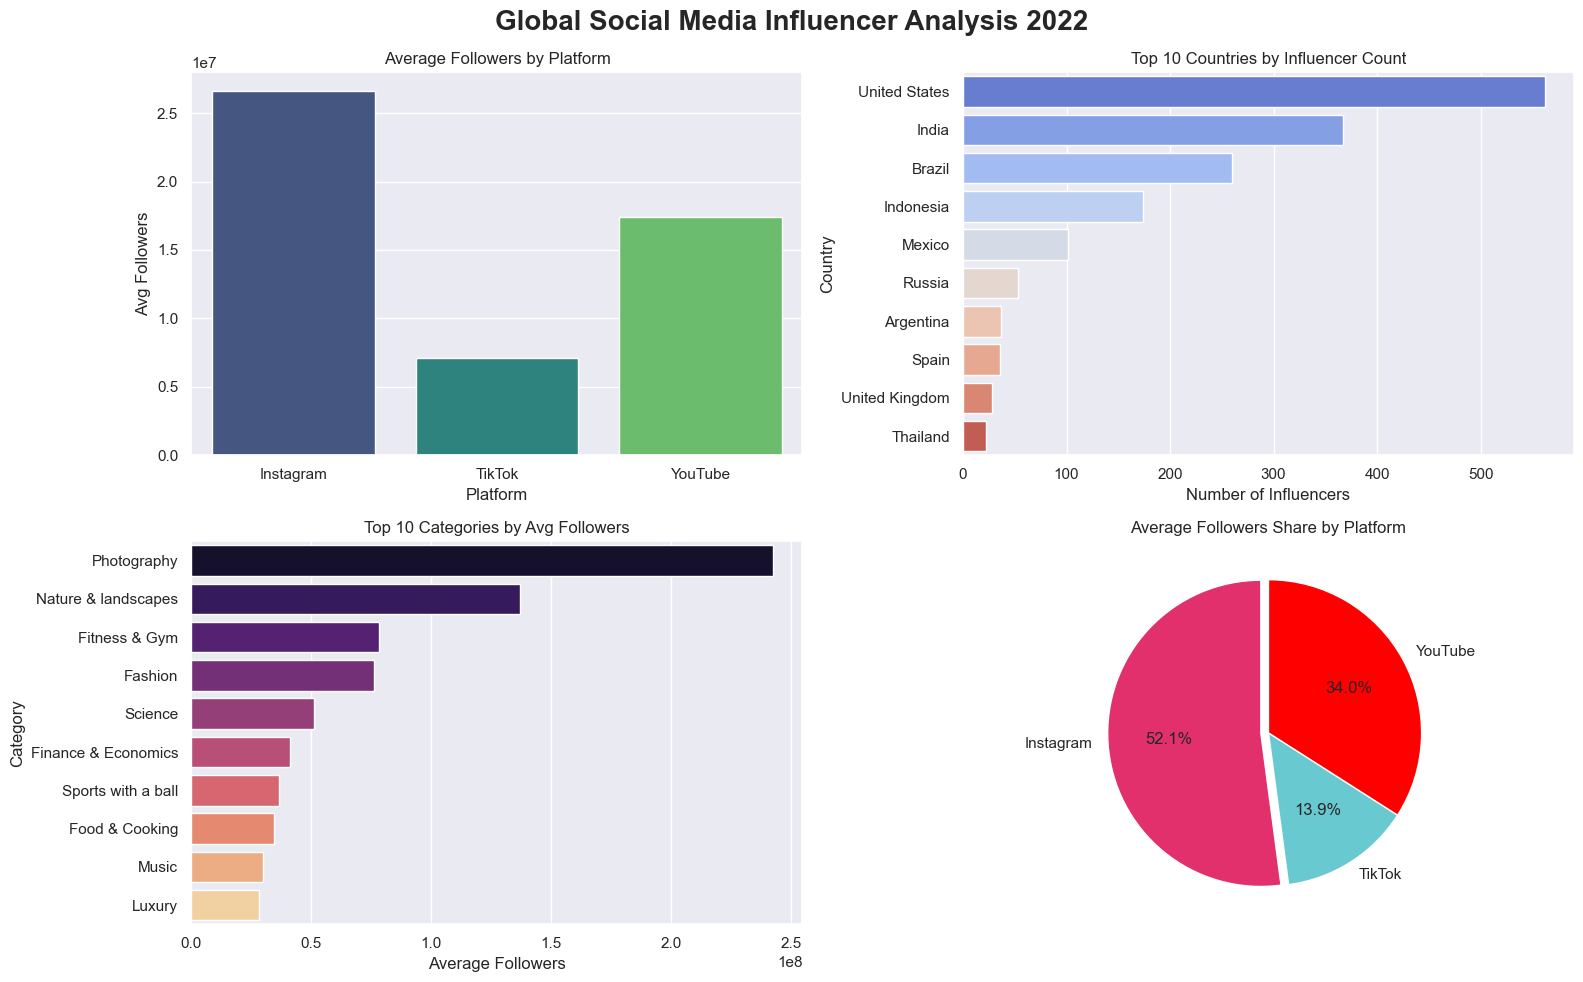

 Dashboard saved!


In [28]:
#  CELL DASHBOARD 
sns.set_theme(style='darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Global Social Media Influencer Analysis 2022',
             fontsize=20, fontweight='bold')

# Chart 1 - Avg followers per platform
platform_avg = df.copy()
platform_avg['Followers'] = platform_avg['Followers'].apply(convert_followers)
platform_avg = platform_avg.groupby('Platform')['Followers'].mean().reset_index()
platform_avg.columns = ['Platform', 'Followers']
sns.barplot(x='Platform', y='Followers', data=platform_avg,
            hue='Platform', legend=False, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Average Followers by Platform')
axes[0, 0].set_ylabel('Avg Followers')

# Chart 2 - Top countries
sns.barplot(x='Count', y='Country', data=top_countries,
            hue='Country', legend=False, palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Countries by Influencer Count')
axes[0, 1].set_xlabel('Number of Influencers')

# Chart 3 - Top categories
sns.barplot(x='Followers', y='Category', data=top_cats,
            hue='Category', legend=False, palette='magma', ax=axes[1, 0])
axes[1, 0].set_title('Top 10 Categories by Avg Followers')
axes[1, 0].set_xlabel('Average Followers')

# Chart 4 - Avg followers share
avg_followers = df.copy()
avg_followers['Followers'] = avg_followers['Followers'].apply(convert_followers)
avg_followers = avg_followers.groupby('Platform')['Followers'].mean().reset_index()
axes[1, 1].pie(avg_followers['Followers'],
               labels=avg_followers['Platform'],
               autopct='%1.1f%%',
               colors=['#E1306C', '#69C9D0', '#FF0000'],
               startangle=90,
               explode=(0.05, 0, 0))
axes[1, 1].set_title('Average Followers Share by Platform')

plt.tight_layout()
plt.savefig('influencer_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Dashboard saved!")

In [29]:

with pd.ExcelWriter('influencer_report.xlsx', engine='openpyxl') as writer:
    Platform_summary.to_excel(writer, sheet_name='Platform Summary', index=False)
    top_countries.to_excel(writer, sheet_name='Top Countries', index=False)
    top_cats.to_excel(writer, sheet_name='Top Categories', index=False)
    df[['Influencer', 'Platform', 'Followers', 'Country', 'Category']]\
        .sort_values('Followers', ascending=False)\
        .head(50)\
        .to_excel(writer, sheet_name='Top 50 Influencers', index=False)

print(" Excel report exported!")

 Excel report exported!


In [32]:
# Key numbers for conclusion
top_platform = df.copy()
top_platform['Followers'] = top_platform['Followers'].apply(convert_followers)
top_platform = top_platform.groupby('Platform')['Followers'].mean().idxmax()
top_country = df[df['Country'] != 'Unknown']['Country'].value_counts().index[0]
top_category = (df[df['Category'] != 'Unknown'].copy()
                .assign(Followers=df[df['Category'] != 'Unknown']['Followers'].apply(convert_followers))
                .groupby('Category')['Followers'].mean().idxmax())
top_influencer = df.loc[df['Followers'].idxmax(), 'Influencer']

print(f"Top Platform: {top_platform}")
print(f"Top Country: {top_country}")
print(f"Top Category: {top_category}")
print(f"Top Influencer: {top_influencer}")

Top Platform: Instagram
Top Country: United States
Top Category: Photography
Top Influencer: jomaryee


##  Key Findings & Recommendations

###  Summary Stats
- **3,000 influencers** analyzed across 3 platforms
- **10 countries** represented in top markets
- **Instagram** dominates with the highest average followers
- **Cristiano Ronaldo** is the most followed influencer globally (523M)

### Key Findings

| # | Finding | Detail |
|---|---------|--------|
| 1 | Instagram leads in reach | Highest average followers across all platforms |
| 2 | United States dominates | Most influencers come from the US |
| 3 | Photography drives engagement | Highest average followers by category |
| 4 | TikTok data gap | No country data available — limits geographic analysis |
| 5 | Top influencer is jomaryee | Highest followers in the combined dataset |

###  Recommendations

**1. Brand Partnerships**
> Prioritize Instagram influencers for maximum audience reach.
> Photography and Nature content categories deliver the highest follower counts.

**2. Geographic Strategy**
> Focus campaigns in the United States, India and Brazil —
> the top 3 countries by influencer count.

**3. Content Strategy**
> Photography, Nature & Landscapes and Fitness & Gym
> are the highest performing categories.
> Brands in these niches have the largest potential audience.

**4. Data Quality**
> TikTok country data is missing for 999 out of 999 influencers.
> Collecting this data would unlock geographic targeting on TikTok.

### Final Takeaway
> Instagram is the most powerful platform for influencer reach in 2022.
> A US-focused Photography or Fitness campaign with Instagram influencers
> represents the highest ROI opportunity based on this dataset.